# 📊 CUSTOMER SERVICE REQUEST ANALYSIS PROJECT


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
import warnings
warnings.filterwarnings("ignore")

# Import Dataset


In [2]:
df = pd.read_csv('Desktop/311_Service_Requests_from_2010_to_Present.csv')
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


# dataset information

In [4]:
print(df.columns)
print(df.shape)
print(df.isnull().sum())


Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

# Null Value Visualization

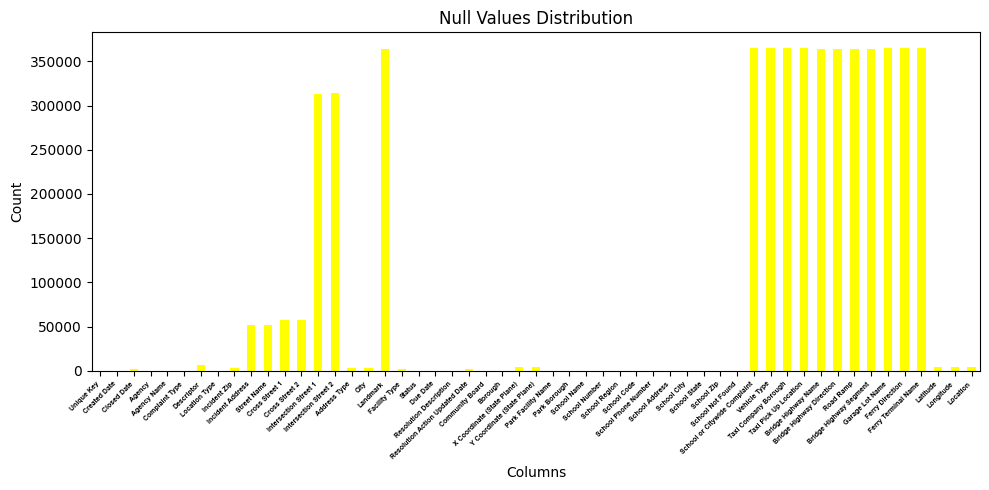

In [6]:
plt.figure(figsize=(10,5))
df.isnull().sum().plot(kind='bar', color='yellow')
plt.title("Null Values Distribution", fontsize=12)
plt.xlabel("Columns", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=5, fontname='Arial',fontweight='bold')
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


# Convert Date Columns

In [7]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

# Remove Null Closed Date


In [8]:
df = df.dropna(subset=['Closed Date'])

# Fill Missing City

In [9]:
df['City'] = df['City'].fillna('Unknown City')

# Time Analysis

In [9]:
df['Request_Closing_Time'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds()

# statistics

In [10]:
df['Request_Closing_Time'].describe()

count    3.621770e+05
mean     1.511330e+04
std      2.110255e+04
min      6.100000e+01
25%      4.533000e+03
50%      9.616000e+03
75%      1.887800e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

# Complaint Analysis

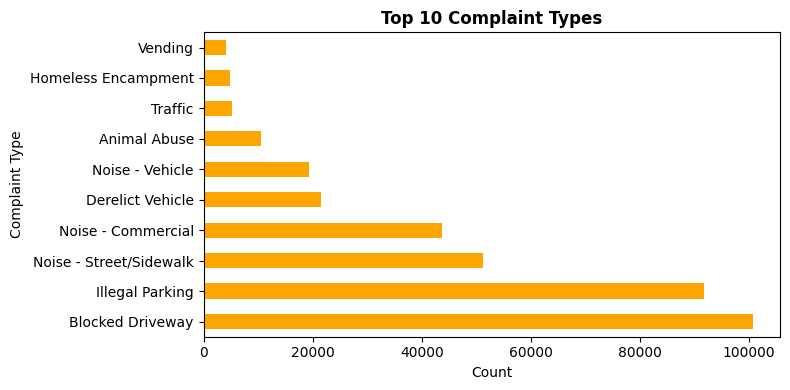

In [77]:

plt.figure(figsize=(8,4))
df['Complaint Type'].value_counts().head(10).plot(kind='barh', color='orange')
plt.title("Top 10 Complaint Types", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Complaint Type")
plt.tight_layout()
plt.show()

# 🔶 City-wise Complaints ⭐

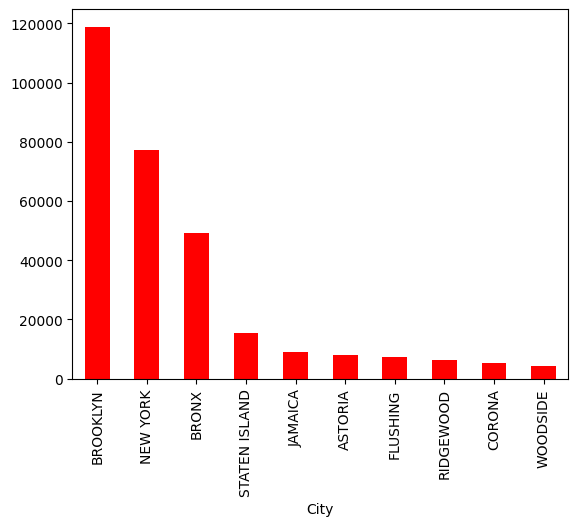

In [78]:
df['City'].value_counts().head(10).plot(kind='bar',color='red')
plt.show()

# 🔶 5. Hourly Trend Analysis ⭐

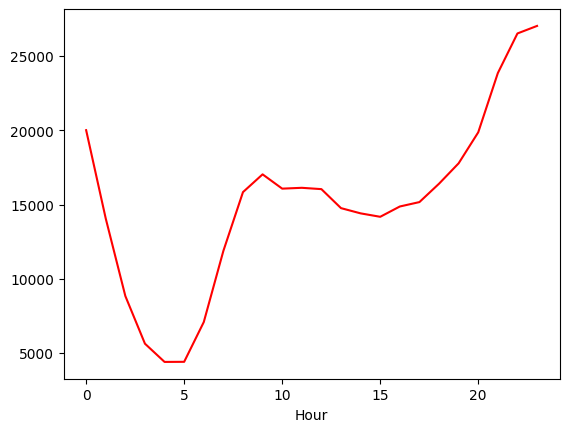

In [82]:
df['Hour'] = df['Created Date'].dt.hour
df['Hour'].value_counts().sort_index().plot(kind='line' ,color='red')
plt.show()

# Complaint Type vs City

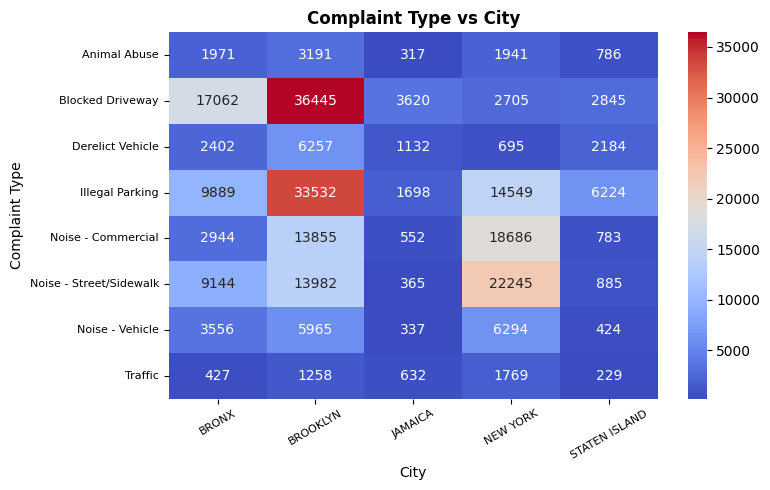

In [73]:

top_complaints = df['Complaint Type'].value_counts().head(8).index
top_cities = df['City'].value_counts().head(5).index
df_filtered = df[df['Complaint Type'].isin(top_complaints) & df['City'].isin(top_cities)]
df_new = pd.crosstab(df_filtered['Complaint Type'], df_filtered['City'])
plt.figure(figsize=(8,5))
sns.heatmap(df_new, cmap='coolwarm', annot=True, fmt='d')
plt.title("Complaint Type vs City", fontsize=12, fontweight='bold')
plt.xticks(rotation=30, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Advanced Visualization

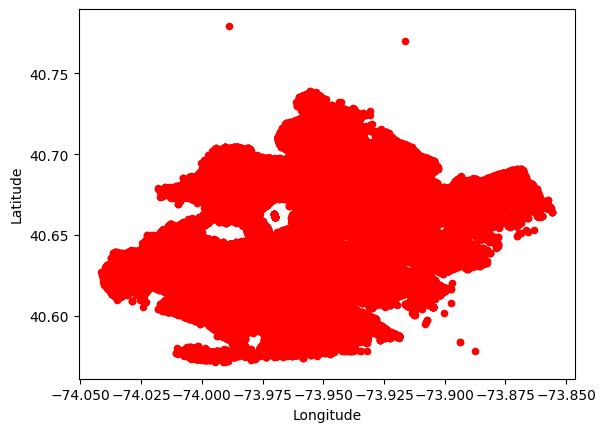

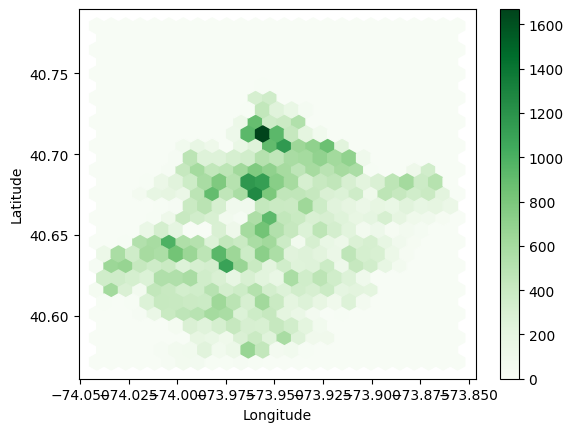

In [99]:
brooklyn = df[df['City']=='BROOKLYN']
brooklyn.plot.scatter(x='Longitude', y='Latitude',color='red')
plt.show()
brooklyn.plot.hexbin(x='Longitude', y='Latitude', gridsize=25,cmap='Greens')
plt.show()

# Average Response Time Analysis

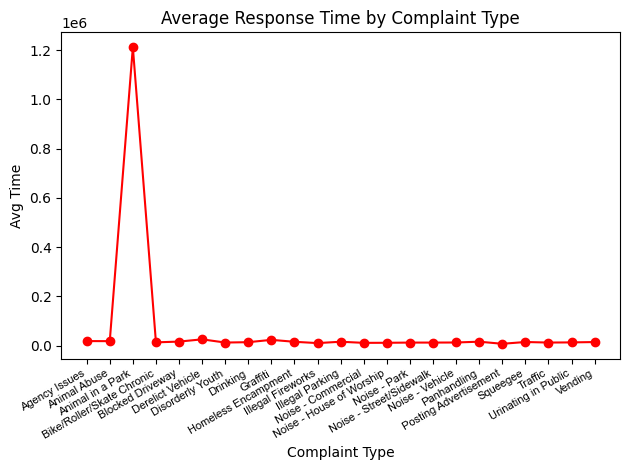

In [84]:

plt.plot(avg_time.index, avg_time.values, marker='o',color='red')
plt.title("Average Response Time by Complaint Type", fontsize=12)
plt.xlabel("Complaint Type", fontsize=10)
plt.ylabel("Avg Time", fontsize=10)

plt.xticks(rotation=30, ha='right',fontsize=8,fontname='Arial')
plt.tight_layout()

plt.show()

# Statistical Analysis

In [17]:
type1 = df[df['Complaint Type']=='Noise']['Request_Closing_Time']
type2 = df[df['Complaint Type']=='Water Leak']['Request_Closing_Time']
stats.ttest_ind(type1, type2)

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

# Kruskal-Wallis Test

In [18]:
groups = [group['Request_Closing_Time'].values for name, group in df.groupby('Complaint Type')]
stat, p = kruskal(*groups)
print("P-value:", p)

P-value: 0.0


# Interpretations

Based on the Kruskal-Wallis test, the p-value is less than 0.05.
Therefore, we reject the null hypothesis (H0). This indicates that there is a significant difference 
in response times across different complaint types.

# OBESRVATIONS

1. Most complaints are concentrated in a few major cities.
2. Certain complaint types (like Noise, Water Issues, etc.) occur more frequently than others.
3. Complaint activity varies throughout the day, with peak hours showing higher requests.
4. Some locations show higher complaint density, indicating problem hotspots.
5. The time taken to resolve complaints is not the same for all complaint types.
6. A few complaint categories take significantly longer to resolve.
7. There is a noticeable variation in complaint patterns across different cities.